# EDA Process

Loading Data

In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')

Initail Inspection On Dataset

1->First Look Of Data

In [4]:
dataset.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


2->Columns Names and Variable Types

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

3->Statistic Summary

In [6]:
dataset.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


Checking Missing Values

In [3]:
dataset.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [7]:
import seaborn as sns

<Axes: >

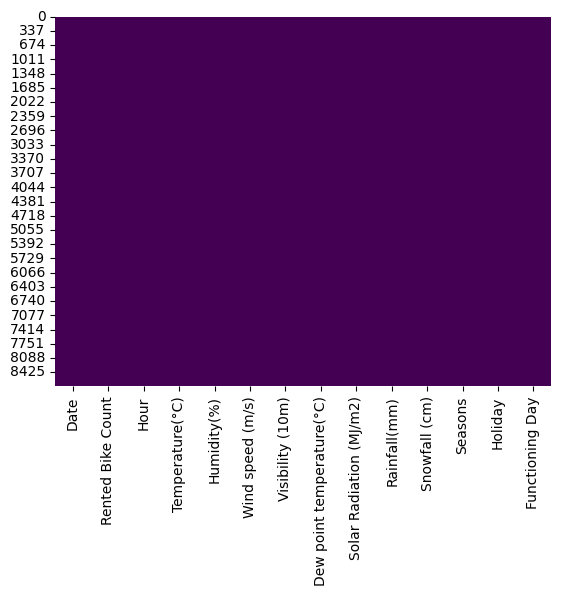

In [8]:
sns.heatmap(dataset.isnull(),cbar=False,cmap='viridis')

Needed Conversions

In [10]:
dataset['Date']=pd.to_datetime(dataset['Date'],dayfirst=True)
dataset['Seasons']=dataset['Seasons'].astype('category')
dataset['Holiday']=dataset['Holiday'].astype('category')
dataset['Functioning Day']=dataset['Functioning Day'].astype('category')

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   category      
 12  Holida

Univariate Analysis

In [12]:
from matplotlib import pyplot as plt

1->Numerical Columns

a->Histogram

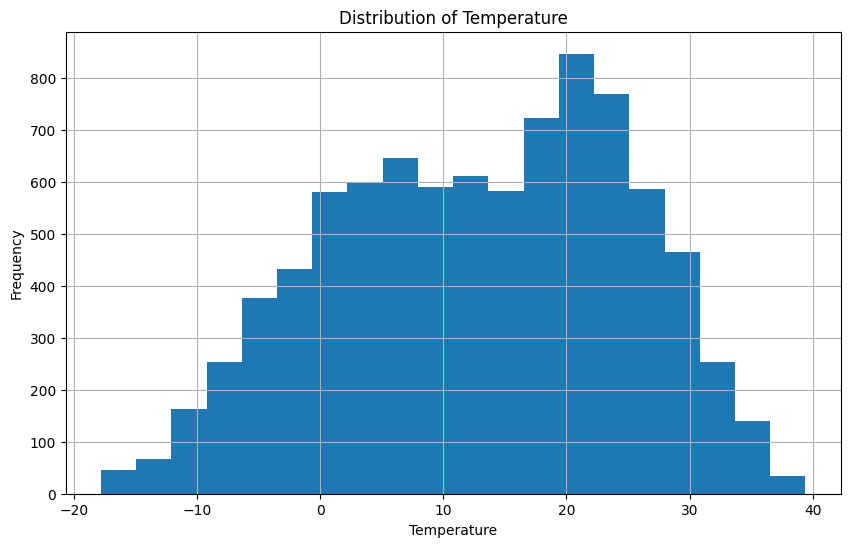

In [14]:
dataset['Temperature(°C)'].hist(bins=20, figsize=(10, 6))
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

Histogram: Visualizes the frequency distribution of a continuous variable.

b-> Box Plot

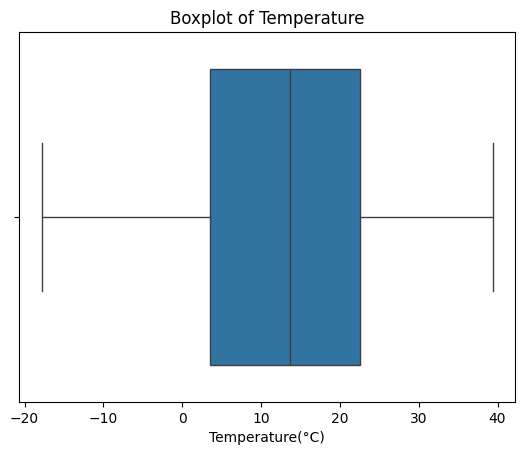

In [16]:
sns.boxplot(x=dataset['Temperature(°C)'])
plt.title('Boxplot of Temperature')
plt.show()

Boxplot: Highlights the median, quartiles, and potential outliers.

You’ll want to understand the distribution of each numeric column. Visualizing distributions (e.g., histograms, box plots) helps identify patterns, outliers, and skewness.

2->Categorical Columns

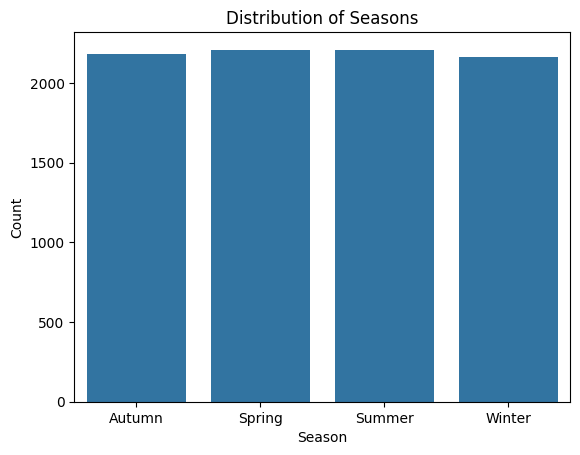

In [18]:
sns.countplot(x='Seasons', data=dataset)
plt.title('Distribution of Seasons')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

Countplot: Shows the frequency distribution of a categorical variable.

For categorical variables, bar plots or count plots are useful to visualize the frequency of each category.

Bivariate Analysis

1->Numerical vs. Numerical

Scatter Plot

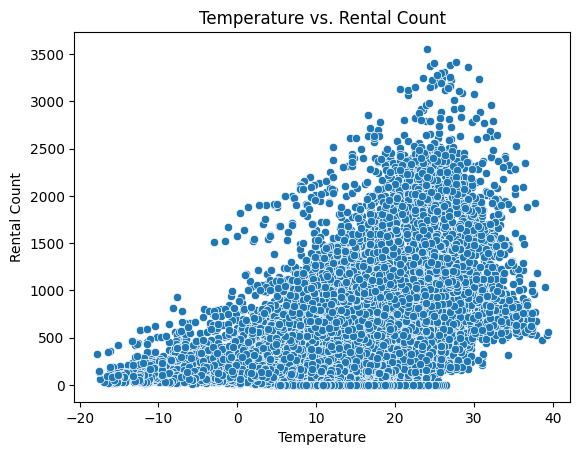

In [19]:
sns.scatterplot(x='Temperature(°C)', y='Rented Bike Count', data=dataset)
plt.title('Temperature vs. Rental Count')
plt.xlabel('Temperature')
plt.ylabel('Rental Count')
plt.show()

Scatterplot: Helps you visually identify correlations and trends.

Correlation Matrix Of All Numerical Columns

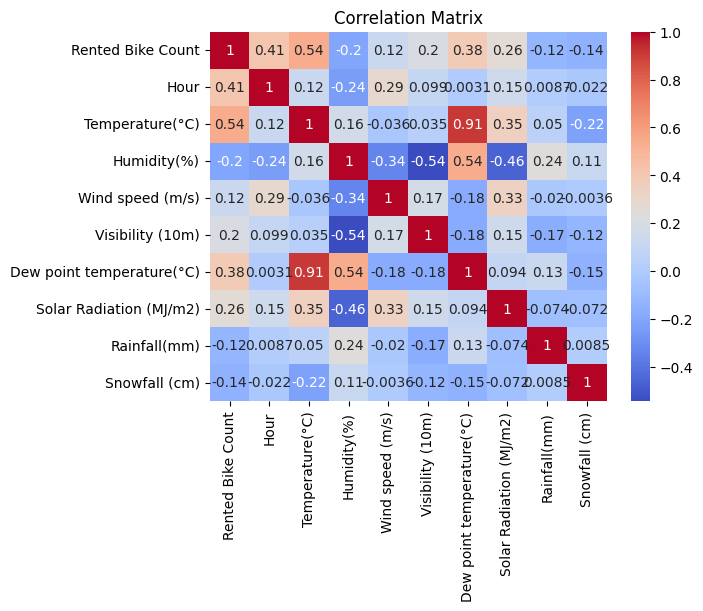

In [22]:
corr_matrix = dataset.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Correlation matrix: Shows how strongly the numerical columns are correlated. You can find potential relationships between weather, time, and rental demand

2->Categorical vs Numerical

Box Plot

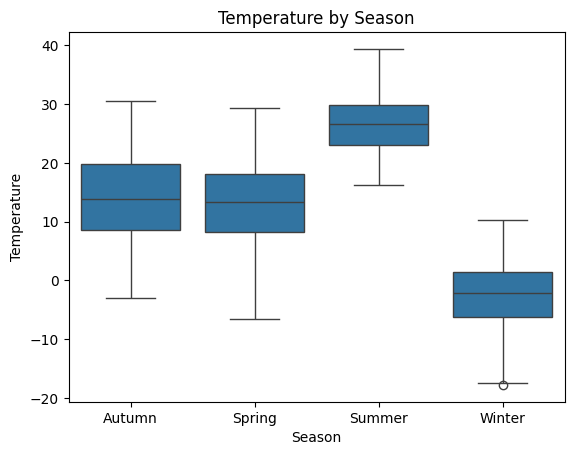

In [23]:
sns.boxplot(x='Seasons', y='Temperature(°C)', data=dataset)
plt.title('Temperature by Season')
plt.xlabel('Season')
plt.ylabel('Temperature')
plt.show()

Violin Plot

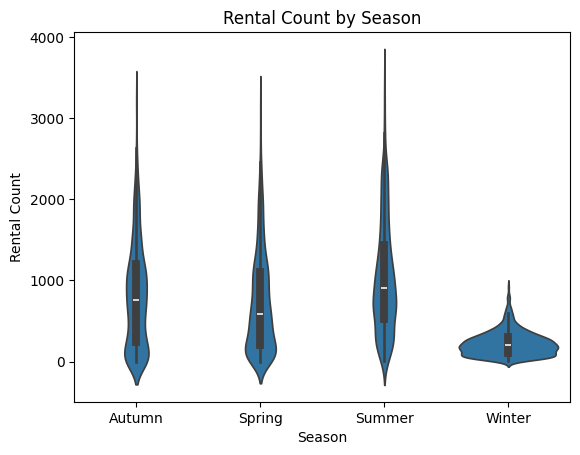

In [25]:
sns.violinplot(x='Seasons', y='Rented Bike Count', data=dataset)
plt.title('Rental Count by Season')
plt.xlabel('Season')
plt.ylabel('Rental Count')
plt.show()

Boxplot/Violin plot: Helps you compare the distribution of a numerical variable across different categories.

Time Series Analysis

Data should contain time column

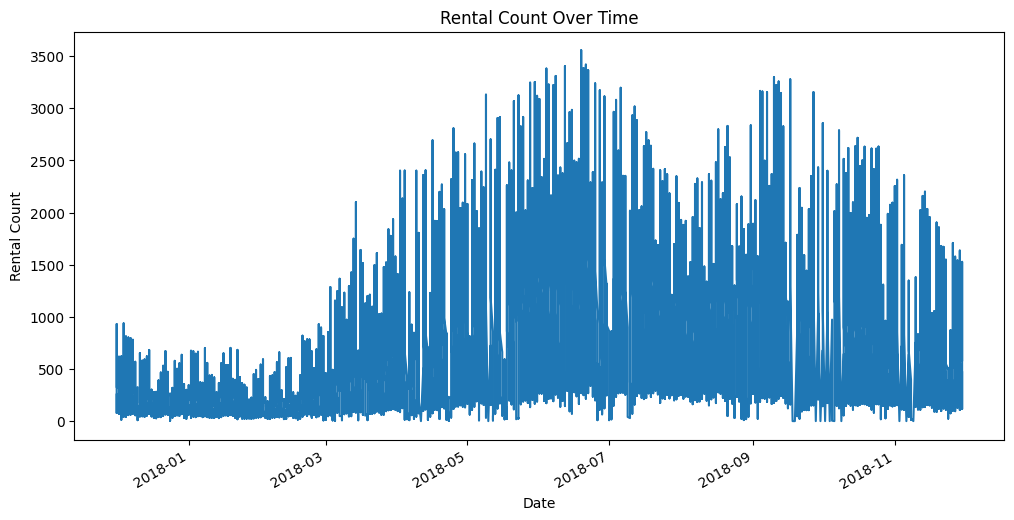

In [26]:
dataset.set_index('Date', inplace=True)
dataset['Rented Bike Count'].plot(figsize=(12, 6))
plt.title('Rental Count Over Time')
plt.xlabel('Date')
plt.ylabel('Rental Count')
plt.show()

Resampling(Like Month, Day etc.)

C:\Users\fvcds\AppData\Local\Temp\ipykernel_13128\1151539421.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rentals = dataset['Rented Bike Count'].resample('M').sum()


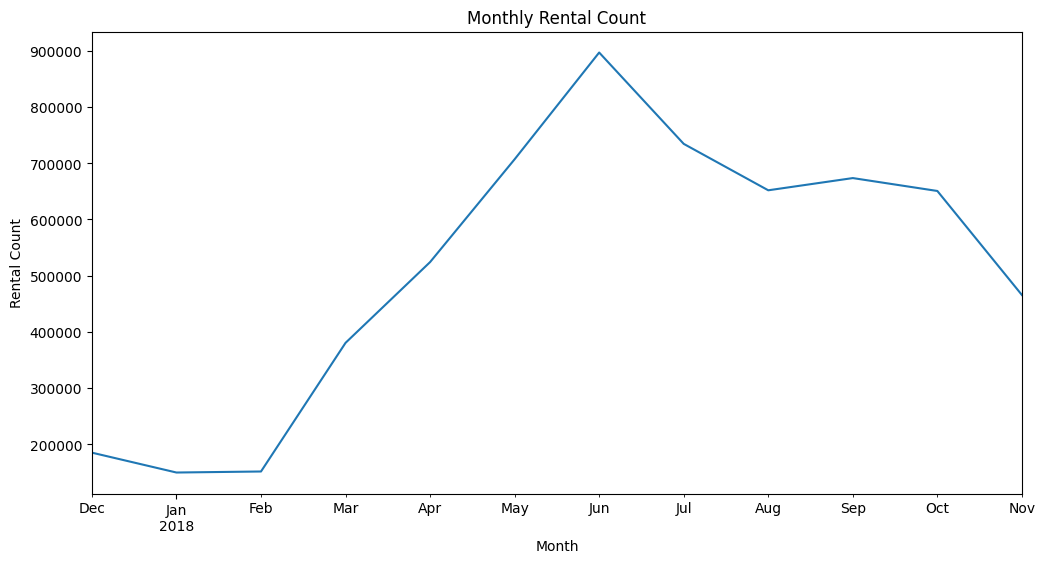

In [27]:
monthly_rentals = dataset['Rented Bike Count'].resample('M').sum()
monthly_rentals.plot(figsize=(12, 6))
plt.title('Monthly Rental Count')
plt.xlabel('Month')
plt.ylabel('Rental Count')
plt.show()

Time series plot: Helps you analyze trends over time, such as seasonality or trends in bike rentals.

Resampling: Aggregates the data by time periods (monthly, weekly) for a clearer analysis.

Detecting Outliers

In [38]:
from scipy.stats import zscore

dataset['z_score'] = zscore(dataset['Temperature(°C)'])
outliers = dataset[dataset['z_score'].abs() > 3]

# Remove outliers (if necessary)
df_no_outliers = dataset[dataset['z_score'].abs() < 3]

In [39]:
print(outliers)

Empty DataFrame
Columns: [Rented Bike Count, Hour, Temperature(°C), Humidity(%), Wind speed (m/s), Visibility (10m), Dew point temperature(°C), Solar Radiation (MJ/m2), Rainfall(mm), Snowfall (cm), Seasons, Holiday, Functioning Day, z_score]
Index: []


In [41]:
print(df_no_outliers.sum(numeric_only=True))

Rented Bike Count            6.172314e+06
Hour                         1.007400e+05
Temperature(°C)              1.128544e+05
Humidity(%)                  5.100620e+05
Wind speed (m/s)             1.511020e+04
Visibility (10m)             1.258659e+07
Dew point temperature(°C)    3.568660e+04
Solar Radiation (MJ/m2)      4.985410e+03
Rainfall(mm)                 1.302500e+03
Snowfall (cm)                6.576000e+02
z_score                      8.526513e-13
dtype: float64


Z-score: Measures how far a data point is from the mean in terms of standard deviations. A Z-score above 3 or below -3 typically indicates an outlier.

Feature Engineering

In [ ]:
dataset['Day_of_week'] = dataset['Date'].dt.dayofweek
dataset['Month'] = dataset['Date'].dt.month

Feature Correlation and Selection

After performing EDA, it's time to look at correlations and possibly drop redundant features that don’t add much value to your model.

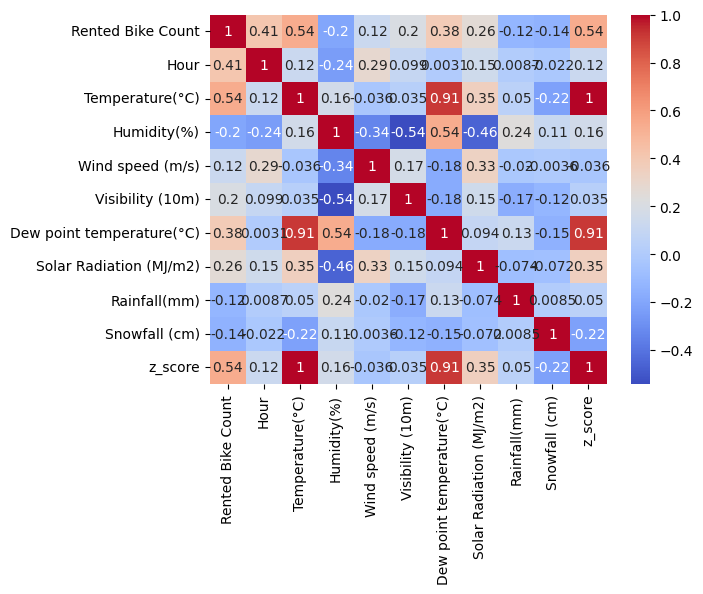

In [ ]:
corr_matrix = dataset.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [47]:
# Droping zscore because temperature and zscore are highly correlated
df = dataset.drop(columns=['z_score'])